# **MODELOS DE LINGUAGEM E EMBEDDINGS**

## **MODELOS DE LINGUAGEM**

Um modelo de linguagem estatístico descreve o quão provável é uma sequência de palavras no idioma que ele modela. Ele faz isso atribuindo uma probabilidade a cada sequência de palavras possível. Uma sequência correta e comum de palavras recebe uma alta probabilidade, e uma sequência incorreta ou incomum de palavras recebe uma baixa probabilidade.

No material anterior, a rede feita para autocompletar textos faz exatamente isso, porém, ela faz usando caracteres como blocos de construção, enquanto um modelo de linguagem costuma utilizar palavras como blocos de construção.

*Um modelo de linguagem estatístico é tipicamente formulado em termos de probabilidades condicionais, onde a probabilidade da próxima palavra em uma sequência é condicionada a todas as palavras anteriores na sequência.*

A figura abaixo exemplifica o *beam search*, usado também no material passado, baseado em palavras. Com o *beam size* de 2 e alimentando a rede com a palavra *"Deep"*, o modelo pode atribuir uma alta probabilidade às seguintes palavras: *"learning"* e *"dish"*. Outras palavras (por exemplo, *"heaven", "bicycle", "talked"*) receberão uma baixa probabilidade. O raciocínio aqui é que, embora *"deep heaven"* e *"deep bicycle"* sejam frases plausíveis, elas parecem improváveis devido aos significados das palavras. É importante notar que podemos construir múltiplos modelos de linguagem para um determinado idioma, dependendo do contexto em que será usado. Em geral, as propriedades do modelo de linguagem dependem do **corpus de texto** do qual ele é derivado.

*Corpus, nesse contexto, refere-se ao conjunto de textos que serve como banco de dados de linguagem para análise, treinamento e/ou avaliações de modelos.*

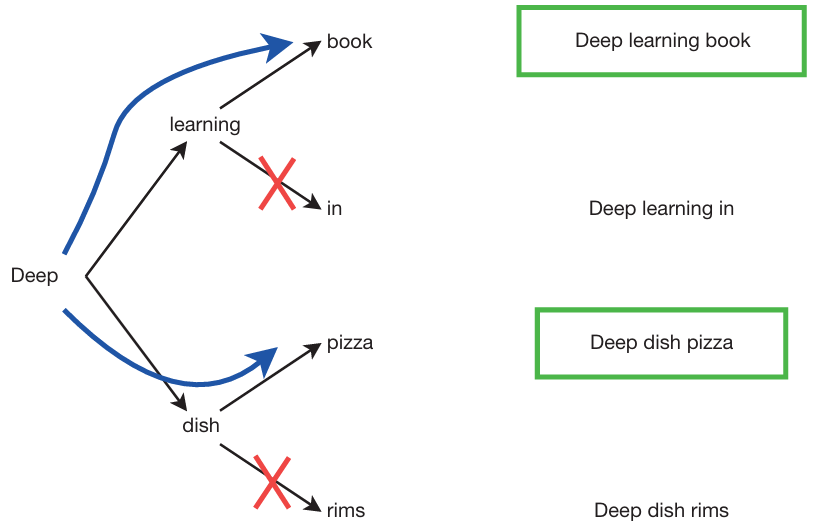 *Beam search baseado em palavras*


Abaixo, serão citados dois exemplos de muitos casos de uso de um modelo de linguagem no campo do processamento de linguagem natural.

O primeiro exemplo é o reconhecimento de fala. Como comentado no material anterior, no contexto das *RNNs Bidirecionais*, pode ser útil olhar tanto para as palavra históricas quanto para as futuras em uma frase ao fazer o reconhecimento de fala. Um modelo de reconhecimento de fala, por exemplo, pode não compreender corretamente uma frase dita. Nesse caso, podemos aplicar um modelo de linguagem para selecionar a frase que for mais provável de ter sido dita, melhorando drasticamente a qualidade do reconhecimento de fala.

O segundo exemplo é a tradução automática de linguagem natural, onde o modelo de linguagem desempenha um grande papel. Primeiro, várias traduções candidatas são produzidas usando uma de várias técnicas existentes. Uma dessas técnicas é primeiro fazer uma tradução palavra por palavra e, em seguida, criar diferentes permutações de como as palavras são ordenadas (diferentes idiomas geralmente têm diferentes ordens de palavras). Um modelo de linguagem pode então ser usado para identificar a tradução candidata mais provável.

*OBS.: Esses exemplos acima ainda são muitos simples em relação ao que as redes mais atuais fazem nessas áreas.* 

### **EXEMPLOS DE ALGUNS MODELOS DE LINGUAGEM**

#### **n-GRAM**

É um modelo de linguagem estatístico simples. Como mecionado acima, um modelo de linguagem tenta resolver o problema de fornecer uma probabilidade para cada palavra em um vocabulário, dada uma sequência de palavras históricas. O modelo do *n-gram* aproxima isso considerando apenas as (n-1) palavras mais recentes, em vez de usar todas as palavras anteriores. Essas (n-1) palavras históricas mais a próxima palavra prevista pelo modelo formam uma sequência de *n* palavras, conhecida como *"n-gram"*, que dá nome ao modelo.

Esse *n* é um hiperparâmetro escolhido antes de treinar o modelo. Um exemplo desse modelo, que é amplamente conhecido, é o *bigram*, quando o n é igual a 2. Esse modelo é construído contando todos os diferentes bigramas no *corpus* de treinamento e, em seguida, baseando a previsão na frequência que cada bigrama aparece. Como exemplo, considere a seuquência de palavras "Quanto mais eu leio, mais eu aprendo, e eu gosto disso mais do que qualquer outra coisa." Para simplificar, ignoramos a pontuação e convertemos todos caracteres para minúsculos. Com isso podemos construir a seguinte lista de bigramas: /quanto mais/, /mais eu/, /eu leio/, /leio mais/, /mais eu/, /eu aprendo/, e assim por diante até /outra coisa/.

Observa-se que o bigrama /mais eu/ aparece mais de uma vez, os bigramas não idênticos /eu leio/, /eu aprendo/, /eu gosto/ e /mais eu/, /mais do/ têm a mesma palavra inicial. OS bigramas estão representados na tabela abaixo, ordenados alfabeticamente.

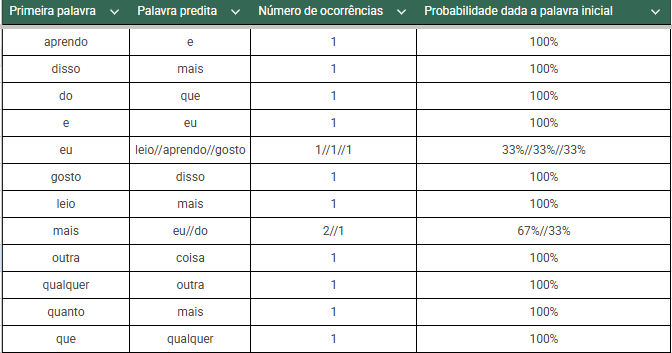 *Os bigramas*

A partir dessa tabela, conseguimos, dada uma palavra inicial, prever a próxima palavra. Por exemplo, se nos for dada a palavra *e*, nosso modelo bigrama prevê que a probabilidade da próxima palavra ser *eu* é de 100% e a probabilidade das outras palavras é 0%. Se a primeira palavra for *mais*, o modelo irá prever uma probabilidade de 67% para a palavra *eu* e 33% para a palavra *do*.

Com isso, nota-se que o modelo de bigrama é limitado por não capturar dependências de longo prazo. Por exemplo, se treinarmos o modelo nas frases “the boy reads,” “the girl reads,” e “the boy and girl read,” e depois apresentarmos “the boy and girl” como uma sequência inicial, o modelo bigrama ignorará “the boy and” e preverá a próxima palavra com base apenas na palavra *girl*. Sua probabilidade para *reads* é de 50%, e sua probabilidade para *read* é de 50%, embora o contexto mais longo deixe claro que a palavra *read* deveria ser mais provável. A solução óbvia é aumentar o valor de n. Podemos, com isso, criar um modelo 5-grama, isso permite que o modelo aumente sua habilidade de capturar essas dependências de longo prazo, porém, tem a desvantagem de que serão necessários muito mais dados de treinamento para capturar 5-gramas suficientes para tornar o modelo bom. Se a sequência inicial não puder ser encontrada na tabela, então o modelo prevê 0%, o que é uma limitação significativa do modelo n-grama básico. Isso é agravado pelo fato de que quanto mais longos os n-grmas, menor é a chance de que a sequência passada pro modelo seja exatamente igual a uma sequência no *corpus* de treinamento. Por exemplo, o *corpus* de treinamento pode ter contido a sequência “the boys and girls read,” mas o modelo ainda não pode prever nada quando apresentado à sequência de entrada “the boy and girl” porque *boy* e *girl* estão agora no singular. Ainda assim, o modelo n-grama básico demonstrou ser útil, e existem várias extensões que abordam algumas de suas deficiências.

#### **SKIP-GRAM**

Esse modelo é uma extensão do modelo *n-gram*, mas onde nem todas as palavras precisam aparecer sequencialmente no *corpus* de treinamento. Em vez disso, algumas palavras podem ser puladas. Um modelo *k-skip-n-gram* é definido pelos hiperparâmetros *k* e *n*, onde o *k* determina quantas palavras podem ser puladas e *n* determina quantas palavras cada *skip-gram* contém. Por exemplo, um modelo *1-skip-2-gram* contera todos os bigramas que foram discutidos acima e, também conterá, pares de palavras não consecutivas que são separadas por, no máximo, uma palavra.

#### **NEURAL**

Se tratando de um modelo de linguagem neural baseado em palavras, como podemos codificar essas palavras para passarmos para o modelo. Podemos pensar que as palavras podem ser codificadas em *one-hot*, porém vem em mente os desafios e as desvantagens que isso apresenta. Como solução, temos os ***word embeddings***.

A figura abaixo mostra três arquiteturas de modelos de linguagem neurais. A primeira versão é uma rede *feedforward* simples que recebe uma única palavra anterior como *input* e termina com uma camada *softmax fully connecyed* que prevê a próxima palavra, semelhante ao *bigram*. Obviamente, um modelo neural que considera apenas a palavra mais recente resultará em uma acurácia limitada, assim como um modelo *bigram*. O modelo no meio implementa uma melhoria óbvia em relação ao modelo anterior. Em vez de fornecer apenas uma única palavra como entrada, o modelo recebe múltiplas palavras, ainda sendo uma rede *feedforward* com uma camada de saída *softmax fully connected*. Desse modo, o número de entradas é dimensionado para aceitar um número fixo de palavras, semelhante ao *n-gram*. A partir disso, nota-se a incapacidade desses modelos de aceitar entradas de tamanho variável. Isso nos leva ao modelo mais à direita na figura, que é um modelo de linguagem neural baseado em uma *RNN*, semelhante a um modelo *n-gram* no qual o *n* pode assumir qualquer valor e pode ser diferente para diferentes exemplos de treinamento e teste.

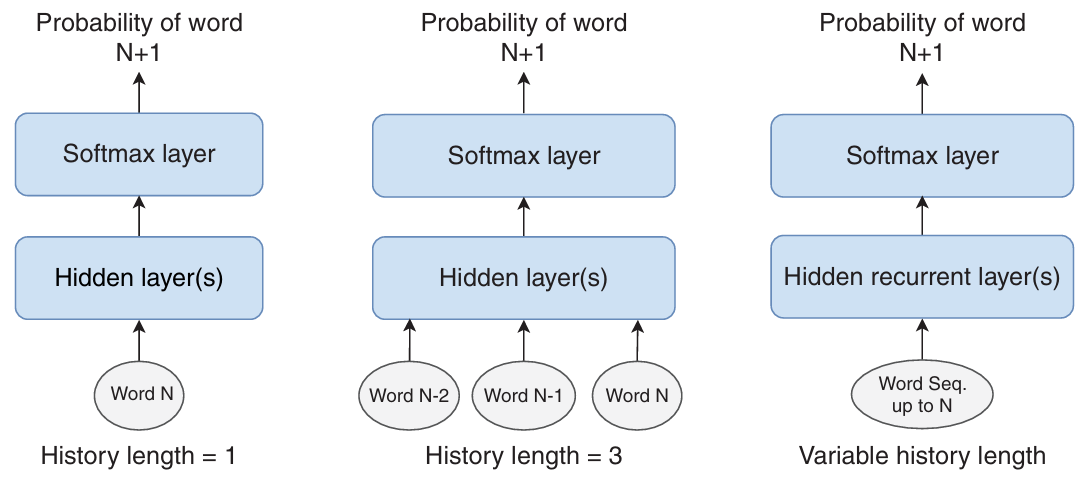 *Modelos de linguagem neurais.*

O que foi dito acima faz parecer que um modelo de linguagem neural não é muito diferente de um modelo *n-gram*, porém isso não é verdade. O modelo *n-gram* é exato,, pois registra as probabilidades exatas dos dados observados (conjunto de treinamento) enquanto o modelo de linguagem é aproximado, já que aprende os pesos para tentar imitar o conjunto de treinamento. A diferença mais importante é a **capacidade de generalização** que os modelos neurais possuem, ou seja, se um modelo *n-gram* for apresentado a uma sequência de palavras que não estava nos dados de treinamento, sua probabilidade de saída sera 0, enquanto o modelo neural produzirá qualquer probabilidade que resulte dos pesos treinandos. Isso não garante que o modelo de linguagem neural fornecerá informações úteis/corretas para um caso nunca visto antes, mas é possível que o modelo neural traga benefícios neste caso. 

## **WORD EMBEDDINGS**

Considere a frase vista no treinamento "o gato está andando no quarto" e a frase vista após o treinamento como "um cão estava correndo em um". Palavra por palavra, elas são frases completamente diferentes. No entanto, as palavras nas duas frases distintas têm semântica e gramática similares. Tanto "um" quanto "o" são artigos. "cão" e "gato" são substantivos que representam animais de estimação. As palavras "está" e "estava" são tempos diferentes do verbo "estar". Dado esse conhecimento de como as diferentes palavras se relacionam, não é exagero supor que a segunda frase deveria terminar com a palavra "quarto". Ou seja, a frase “um cão estava correndo em um quarto” deveria receber uma alta probabilidade, dado nosso conhecimento de que a primeira frase recebe uma alta probabilidade. Queremos que o modelo seja capaz de generalizar e aprende a probabilidade da segunda frase ao ser treinado na primeira. Isso pode ser feito escolhendo um esquema de codificação de palavras com a propriedade de que duas palavras com semântica ou gramática similares recebam codificações similares.

Considere que tenhamos um modelo que apredneu a traduzir do inglês para o francês. Ele aprendeu a tranduzir a frase “that is precisely what I mean”. No entanto, foi solicitado para que ele traduzisse um frase que ele nunca viu, “that is exactly what I mean”. Se a codificação para a palavra *exactly* for similar à codificação para a palavra *precisely*, então o modelo pode assumir que sua tradução aprendida é válida.

Essas propriedades que tanto queremos podem ser alcançadas usando ***word embeddings***. Um *word embedding* é uma representação densa de uma palavra em um espaço vetorial com um número menor de dimensões do que o número de palavras no vocabulário. Agora irei explicar parte por parte dessa definição. De representação **densa**, podemos interpretar como sendo uma representação não "esparsa", ou seja, o vetor que representa uma palavra terá múltiplos elementos não nulos, normalmente, todos os elementos são não nulos. De **espaço vetorial com número de dimensões menor que o número de palavra do vocabulário** é simplemente que ele tera menos elementos que um vetor codificado em *one-hot*, ou seja, ele não terá a mesma quantidade de elementos que de palavras existentes no *corpus* do texto.

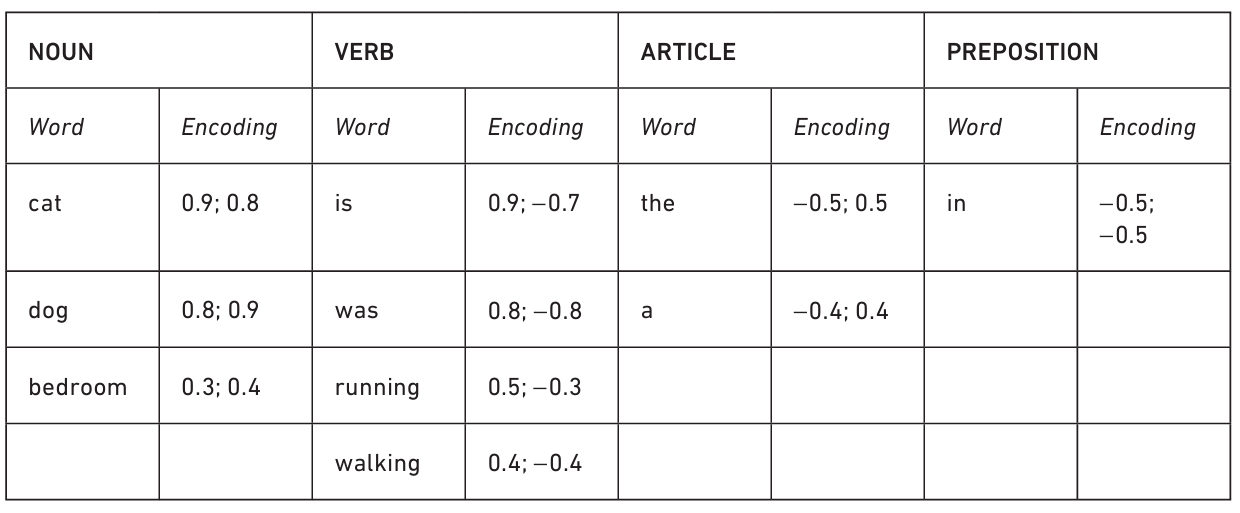 *Representação de um pequeno vocabulário em um embedd de 2 dimensões.*

A figura abaixo plota essas palavras em um espaço 2D, o que nos leva a origem do termo *embedding*: as palavras são embutidas (*embedded*) em um espaço n-dimensional. Da mesma forma, um ponto em um sistema de coordenadas pode ser representado por um vetor, o que explica por que um nome diferente para *embedding* é "vetor de palavras".

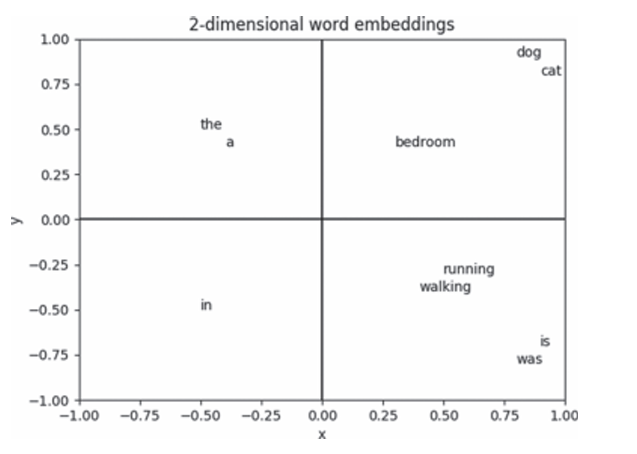 *O embedding dessas palavras em um espaço 2D*

Como pode ser observado na imagem, nesse caso a classe gramatical pode ser deduzida a partir do quadrante que a palavra está localizada. Por exemplo, no primeiro quadrante estão os substantivos. Além disso, dentro de cada quadrante, as palavras que são semelhantes estão localizadas próximas umas das outras.

### **EMBEDDINGS GERADOS POR MODELOS DE LINGUAGEM NEURAIS**

Pesquisadores mostraram que os *embeddings* produzidos ao treinar um modelo de linguagem neural expressam a propriedade de que *embeddings* correspondentes a palavras semanticamente similares estão localizados próximos uns dos outros no espaço vetorial.

Começarei descrevendo como incorporar esses *embeddings* na rede neural para que ele possam ser aprendidos durante o treinamento. Assumindo uma única palavra como entrada para um modelo, uma maneira ingênua de fazer isso é deixar a camada de entrada representar a palavra na forma codificada em *one-hot* e deixar que a primeira camada oculta seja uma camada *fully connected* com *N* neurônios com funções de ativação lineares. A saída desta camada oculta será agora um *word embedding N-dimensional*. O vetor de palavras correspondente à palavra *K* no vocabulário será os pesos do conjunto de conexões que conectam o nó de entrada *K* à camada oculta.

Expandir cada palavra para uma forma codificada em *one-hot* e depois fazer um grande número de multiplicações, a maioria das quais usa 0 como um dos fatores, é ineficiente. Uma maneira mais eficiente de implementar isso é simplesmente representar cada palavra por um índice de valor inteiro e usá-lo para indexar uma tabela de consulta (*lookup table*) que armazena os *embeddings* correspondentes.

Claramente, o modelo de linguagem descrito acima resultará em alguma forma de *word embeddings*. Afinal, os *embeddings* são definidos por quaisquer pesos que o modelo aprenda. No entanto, uma pergunta justa é por que pensaríamos que os *word embeddings* resultantes apresentarão as propriedades que discutimos, como palavras similares tendo *embeddings* similares. Pelo que parece, isso foi mais uma descoberta inesperada que surgiu como um **subproduto**, em oposição a um resultado intencional quando os pesquisadores começaram a experimentar com modelos de linguagem baseados em redes neurais. 

## **HANDS-ON: EXEMPLO DE PROGRAMAÇÃO**

### Código de inicialização

In [14]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Input
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
import tensorflow as tf
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 32
BATCH_SIZE = 256
INPUT_FILE_NAME = r'C:\Users\João Pedro\Documents\LDL\data\frankenstein.txt'
WINDOW_LENGTH = 40
WINDOW_STEP = 3
PREDICT_LENGTH = 3
MAX_WORDS = 10000
EMBEDDING_WIDTH = 100

### Leitura do arquivo e criação dos exemplos de treinamento

In [9]:
#Abrindo e lendo o arquivo
file = open(INPUT_FILE_NAME, 'r', encoding='utf-8')
text = file.read()
file.close()

#Transformando o texto em sequências de palavras individuais e convertendo para minúsculas
text = text_to_word_sequence(text)

#Criando os exemplos de treinamento
fragments = []
targets = []
for i in range(0, len(text) - WINDOW_LENGTH, WINDOW_STEP):
    fragments.append(text[i: i + WINDOW_LENGTH])
    targets.append(text[i + WINDOW_LENGTH])

In [12]:
print(text)

['start', 'of', 'the', 'project', 'gutenberg', 'ebook', '84', 'frankenstein', 'or', 'the', 'modern', 'prometheus', 'by', 'mary', 'wollstonecraft', 'godwin', 'shelley', 'contents', 'letter', '1', 'letter', '2', 'letter', '3', 'letter', '4', 'chapter', '1', 'chapter', '2', 'chapter', '3', 'chapter', '4', 'chapter', '5', 'chapter', '6', 'chapter', '7', 'chapter', '8', 'chapter', '9', 'chapter', '10', 'chapter', '11', 'chapter', '12', 'chapter', '13', 'chapter', '14', 'chapter', '15', 'chapter', '16', 'chapter', '17', 'chapter', '18', 'chapter', '19', 'chapter', '20', 'chapter', '21', 'chapter', '22', 'chapter', '23', 'chapter', '24', 'letter', '1', 'to', 'mrs', 'saville', 'england', 'st', 'petersburgh', 'dec', '11th', '17—', 'you', 'will', 'rejoice', 'to', 'hear', 'that', 'no', 'disaster', 'has', 'accompanied', 'the', 'commencement', 'of', 'an', 'enterprise', 'which', 'you', 'have', 'regarded', 'with', 'such', 'evil', 'forebodings', 'i', 'arrived', 'here', 'yesterday', 'and', 'my', 'first

O próximo passo é converter os exemplos de treinamento para *word embeddings*. Assim, cada palavra de entrada precisa ser codificada em um índice de palavra (um inteiro) correspondente, em vez de uma codificação *one-hot*, como usamos nos materiais passados. Este índice será convertido em um *embedding* pela camada ***Embedding*** da rede. A palavra-alvo ainda será codificada em *one-hot*.

### Convertendo os exemplos de treinamento para os índices de palavras e os *outputs* em *one-hot encoding*

In [10]:
#Convertendo os índices
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='UNK')
tokenizer.fit_on_texts(text)
fragments_indexed = tokenizer.texts_to_sequences(fragments)
targets_indexed = tokenizer.texts_to_sequences(targets)

#Convertendo os inputs e os outputs aos formatos esperados
X = np.array(fragments_indexed, dtype=int)
y = np.zeros((len(targets_indexed), MAX_WORDS))
for i, target_index in enumerate(targets_indexed):
    y[i, target_index] = 1

### Construindo e treinando o modelo

Criação de um modelo com uma camada *Embedding* seguida por duas camadas *LSTMs*, seguidas por uma camada *fully connected* com função de ativação *ReLU* e, por fim, uma camada *fully connected* com uma *softmax* como saída.

In [ ]:
training_model = Sequential()
training_model.add(Embedding(output_dim=EMBEDDING_WIDTH, input_dim=MAX_WORDS, mask_zero=True, input_length=None))
training_model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
training_model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
training_model.add(Dense(128, activation='relu'))
training_model.add(Dense(MAX_WORDS, activation='softmax'))
training_model.compile(loss='categorical_crossentropy', optimizer='adam')
training_model.summary()
history = training_model.fit(X, y, validation_split=0.05, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=2, shuffle=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
94/94 - 87s - 923ms/step - loss: 7.2498 - val_loss: 6.7406
Epoch 2/32
94/94 - 79s - 838ms/step - loss: 6.4475 - val_loss: 6.6950
Epoch 3/32
94/94 - 75s - 794ms/step - loss: 6.3193 - val_loss: 6.6752
Epoch 4/32
94/94 - 68s - 721ms/step - loss: 6.1895 - val_loss: 6.6632
Epoch 5/32
94/94 - 73s - 780ms/step - loss: 6.0290 - val_loss: 6.7233
Epoch 6/32
94/94 - 86s - 914ms/step - loss: 5.9263 - val_loss: 6.7296
Epoch 7/32
94/94 - 80s - 850ms/step - loss: 5.8466 - val_loss: 6.7830
Epoch 8/32
94/94 - 95s - 1s/step - loss: 5.7788 - val_loss: 6.7735
Epoch 9/32
94/94 - 93s - 994ms/step - loss: 5.6952 - val_loss: 6.8303
Epoch 10/32
94/94 - 89s - 949ms/step - loss: 5.6097 - val_loss: 6.8709
Epoch 11/32
94/94 - 77s - 823ms/step - loss: 5.5208 - val_loss: 6.8725
Epoch 12/32
94/94 - 78s - 832ms/step - loss: 5.4448 - val_loss: 6.9861
Epoch 13/32
94/94 - 72s - 767ms/step - loss: 5.3674 - val_loss: 7.0288
Epoch 14/32
94/94 - 73s - 780ms/step - loss: 5.2992 - val_loss: 7.0987
Epoch 15/32
94/94 

A *loss* de treino diminuiu continuamente, enquanto a *loss* de teste diminuiu no começo e voltou a aumentar. Isso é uma indicação de *overfitting*. No entanto, para essa aplicação isso não preocupa muito, pois é difícil acreditar que o nosso modelo seria capaz de prever o enredo de *Frankenstein*. Logo, uma métrica mais comumente usada ao avaliar modelos de linguagem estatísticos é chamada de **perplexidade**.

Após treinar o modelo, ele pode ser usado para fazer previsões. Isso será feito de forma diferente do outro material, pois no outro material, alimentamos o modelo com uma *string* de símbolos, agora o modelo será alimentado com um símbolo de cada vez. Para ficar claro, no material passado, alimentamos o modelo com 'the body' e foi gerado 'w' como saída. No passo seguinte, alimentamos o modelo com 'the body w' e assim por diante. Se tivessemos usado essa implementação no material passado seria assim, teríamos alimentado 't', 'h', 'e', ' ', 'b', 'o', 'd', 'y', ' ', o que teria resultado na saída 'w', e então simplesmente realimentaríamos esse caractere como entrada.

### Criando o modelo de inferência

Esse modelo de inferência pegará os pesos do modelo treinado acima. Para que isso funcione, as redes devem ser idênticas. Usamos esse argumento ```stateful``` para que as camadas *LSTMs* mantenham seu estados de uma chamada para outra, para que as saídas de chamadas subsequentes a ```predict``` dependam das chamadas anteriores.

In [19]:
inference_model = Sequential()
inference_model.add(Input(batch_shape=(1,1)))
inference_model.add(Embedding(output_dim=EMBEDDING_WIDTH, input_dim=MAX_WORDS, mask_zero=True))
inference_model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, stateful=True))
inference_model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, stateful=True))
inference_model.add(Dense(128, activation='relu'))
inference_model.add(Dense(MAX_WORDS, activation='softmax'))
weights = training_model.get_weights()
inference_model.set_weights(weights)

### Implementação da lógica da inferência

In [20]:
first_words = ['i', 'saw']
first_words_indexed = tokenizer.texts_to_sequences(first_words)
predicted_string = ''

for layer in inference_model.layers:
    if hasattr(layer, 'reset_states'):
        layer.reset_states()

#Alimentando as palavras iniciais ao modelo
for i, word_index in enumerate(first_words_indexed):
    x = np.zeros((1, 1), dtype=int)
    x[0][0] = word_index[0]
    predicted_string += first_words[i]
    predicted_string += ' '
    y_predict = inference_model.predict(x, verbose=0)[0]

#Predizendo PREDICT_LENGTH palavras
for i in range(PREDICT_LENGTH):
    new_word_index = np.argmax(y_predict)
    word = tokenizer.sequences_to_texts([[new_word_index]])
    x[0][0] = new_word_index
    predicted_string += word[0]
    predicted_string += ' '
    y_predict = inference_model.predict(x, verbose=0)[0]

print(predicted_string)

i saw the greatest sensations 
